# Proxy TD - Early/Late Window Analysis

Questo notebook usa il proxy takedown come tempo evento `T = last_activity` e studia la finestra utile come **scala temporale del processo pre-evento**, senza usare negativi e senza metriche predittive. L analisi resta quindi volutamente esplorativa: l obiettivo non e classificare gli account, ma capire su quale orizzonte temporale si concentra il segnale osservato prima del proxy evento.

I due regimi vengono trattati separatamente. Per gli `early` l obiettivo e solo capire se abbia senso definire una finestra separata e ottenere una prima stima in giorni; per i `late` l obiettivo e stimare la utility window dalla distribuzione temporale aggregata delle attivita pre-evento. In piu, il notebook controlla se tra questi due livelli emerga anche una possibile scala intermedia, ma senza implementare una terza pipeline.

Dataset usati:
- `datasets/derived/model_proxy_td.parquet`
- `datasets/posts.parquet`

Nota importante:
- `posts.parquet` **non viene mai caricato tutto in memoria**
- viene interrogato via DuckDB con `parquet_scan(...)`, filtrando per `did_id` e per l intervallo realmente osservabile `[A, max(T)]` del campione selezionato


## Workflow

1. carico `model_proxy_td.parquet`
2. ricostruisco `proxy_td` e `duration_days`
3. stimo una soglia `early` data-driven dalla survival dei positivi proxy
4. mostro perche ha senso dividere `early` e `late`
5. costruisco campioni di anchor positivi per i due regimi
6. carico i post solo per questi `did_id` nell intervallo osservabile `[A, max(T)]`
7. escludo un solo post all anchor per account
8. eseguo la pipeline `early` per capire se esiste una finestra separata e stimarne una prima ampiezza
9. eseguo la pipeline `late` basata su tempo relativo, distribuzione aggregata pre-evento ed ECDF cumulata
10. eseguo un diagnostic aggiuntivo per vedere se tra `early` e `late` emerga anche una possibile scala intermedia
11. costruisco la decisione finale, distinguendo chiaramente tra risultato operativo e ipotesi metodologiche future


In [ ]:
from pathlib import Path

A = '2025-01-01'
B = '2025-04-01'
DELTA_DAYS = 30

EARLY_CUT_CANDIDATES = [1, 2, 3, 5, 7, 14]
MIN_EARLY_SHARE = 0.05
MIN_LATE_SHARE = 0.20

EARLY_WINDOWS = [1, 2, 3, 5]
EARLY_COVERAGE_TARGET = 0.80
EARLY_RECOMMENDATION_RULE = 'coverage'

LATE_WINDOWS = [1, 2, 3, 5, 7, 10, 14, 21]
LATE_COVERAGE_TARGET = 0.80
LATE_RECOMMENDATION_RULE = 'coverage'

PRE_EVENT_QUANTILES = [0.50, 0.75, 0.80, 0.90, 0.95]

INTERMEDIATE_MIN_GAP_DAYS = 5
INTERMEDIATE_MIN_MIDDLE_GAIN = 0.10
INTERMEDIATE_MIN_DURATION_SHARE = 0.10

MAX_POSITIVES_EARLY = 1500
MAX_POSITIVES_LATE = 3500
RANDOM_STATE = 42

MIN_SUPPORT_SHARE = 0.25
MIN_SUPPORTED_POSITIVES_EARLY = 500
MIN_SUPPORTED_POSITIVES_LATE = 500

SIGNAL_NAME = 'posts_count'
MODEL_FILE = Path('datasets/derived/model_proxy_td.parquet')
POSTS_FILE = Path('datasets/posts.parquet')


In [ ]:
import sys
import importlib
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)

cwd = Path.cwd()
if (cwd / 'datasets').exists():
    ROOT = cwd
elif (cwd.parent / 'datasets').exists():
    ROOT = cwd.parent
else:
    raise FileNotFoundError('Non riesco a trovare la cartella datasets dal notebook corrente.')

ANALYSIS_DIR = ROOT / 'analysis'
if str(ANALYSIS_DIR) not in sys.path:
    sys.path.append(str(ANALYSIS_DIR))

import analysis.utility_window.proxy_td_informative_window as _proxy_td_informative_window
importlib.reload(_proxy_td_informative_window)

from analysis.utility_window.proxy_td_informative_window import (
    add_proxy_columns,
    assess_intermediate_window_need,
    assign_duration_regime,
    build_positive_anchors,
    compute_structural_support,
    estimate_early_cut_days,
    exclude_one_event_at_reference,
    load_events_from_parquet_duckdb,
    plot_pre_event_global_curve,
    plot_support_vs_utility,
    plot_utility_curve,
    prepare_signal_events,
    run_informative_window_analysis,
)

A_ts = pd.Timestamp(A)
B_ts = pd.Timestamp(B)

print('ROOT =', ROOT)
print('MODEL_FILE =', ROOT / MODEL_FILE)
print('POSTS_FILE =', ROOT / POSTS_FILE)
print('MODULE_FILE =', _proxy_td_informative_window.__file__)


ROOT = c:\Users\Nico\Documents\Bluesky\Bluesky-moderation-analysis
MODEL_FILE = c:\Users\Nico\Documents\Bluesky\Bluesky-moderation-analysis\datasets\derived\model_proxy_td.parquet
POSTS_FILE = c:\Users\Nico\Documents\Bluesky\Bluesky-moderation-analysis\datasets\posts.parquet
MODULE_FILE = c:\Users\Nico\Documents\Bluesky\Bluesky-moderation-analysis\analysis\proxy_td_informative_window.py


In [ ]:
con = duckdb.connect()
accounts = con.execute(f"SELECT * FROM parquet_scan('{(ROOT / MODEL_FILE).as_posix()}')").df()
accounts = add_proxy_columns(accounts, A=A_ts, B=B_ts, delta_days=DELTA_DAYS)
positives = accounts.loc[accounts['proxy_td']].copy()

print('N account nel modello:', len(accounts))
print('N positivi proxy:', len(positives))
print('Share positivi proxy:', round(len(positives) / len(accounts), 4))
display(positives['duration_days'].describe())

EARLY_CUT_DAYS, early_cut_diagnostics = estimate_early_cut_days(
    accounts,
    candidate_days=EARLY_CUT_CANDIDATES,
    min_early_share=MIN_EARLY_SHARE,
    min_late_share=MIN_LATE_SHARE,
)

if EARLY_CUT_DAYS is None:
    raise RuntimeError('Non sono riuscito a stimare una soglia early dai positivi proxy con i criteri correnti.')

accounts = assign_duration_regime(accounts, early_cut_days=EARLY_CUT_DAYS)
positives = accounts.loc[accounts['proxy_td']].copy()
early_label = f'early_<=_{EARLY_CUT_DAYS}d'
late_label = f'late_>_{EARLY_CUT_DAYS}d'
early_mask = accounts['proxy_td'] & (accounts['duration_regime'] == early_label)
late_mask = accounts['proxy_td'] & (accounts['duration_regime'] == late_label)
early_n = int(positives['duration_regime'].eq(early_label).sum())
late_n = int(positives['duration_regime'].eq(late_label).sum())
early_share = early_n / len(positives)
late_share = late_n / len(positives)

early_support_table = compute_structural_support(accounts, EARLY_WINDOWS, positives_mask=early_mask)
late_support_table = compute_structural_support(accounts, LATE_WINDOWS, positives_mask=late_mask)


N account nel modello: 3303665
N positivi proxy: 1419166
Share positivi proxy: 0.4296


count    1.419166e+06
mean     3.112458e+01
std      1.699193e+01
min      2.123843e-05
25%      1.812901e+01
50%      3.064136e+01
75%      4.572682e+01
max      5.999997e+01
Name: duration_days, dtype: float64

## 1. Analisi struttura temporale

Questa sezione usa i risultati derivati da [eda_proxy_model_on_balduf.ipynb](/C:/Users/Nico/Documents/Bluesky/Bluesky-moderation-analysis/analysis/eda_proxy_model_on_balduf.ipynb), in pratica il dataset account-level `model_proxy_td.parquet`, per capire quante scale temporali servano sul piano teorico. La logica e doppia. Primo: guardiamo la struttura delle durate dei proxy positivi con quantili, ECDF e change-point della survival, per verificare se esista davvero un regime `early` distinto. Secondo: usiamo la nuova utility cumulata pre-evento sugli `early` e sui `late` per capire se, oltre alla coppia early/late, emerga anche una possibile scala intermedia. L output di questa sezione non e ancora una pipeline operativa, ma una decisione teorica sul numero di finestre che sembrano giustificate dai dati.


Soglia early stimata: 14 giorni


,cut_day,early_share,late_share,valid_candidate,sse_one_segment,sse_two_segment,sse_improvement,selected
0,1,0.016994,0.983006,False,0.00797,NaN,NaN,False
1,2,0.029617,0.970383,False,0.00797,0.006452,0.001518,False
2,3,0.041823,0.958177,False,0.00797,0.005919,0.002051,False
3,5,0.065883,0.934117,True,0.00797,0.005306,0.002664,False
4,7,0.091722,0.908278,True,0.00797,0.005083,0.002887,False
5,14,0.191368,0.808632,True,0.00797,0.004732,0.003238,True


,group,n_positives,share
0,early,271583,0.191368
1,late,1147583,0.808632


,quantile,duration_days
0,0.50,30.641360
1,0.75,45.726820
2,0.80,48.967843
3,0.90,55.020678
4,0.95,57.920332


Supporto strutturale early:


,window_days,n_positive_total,n_positive_supported,support_share
0,1,271583,247465,0.911195
1,2,271583,229552,0.845237
2,3,271583,212229,0.781452
3,5,271583,178084,0.655726


Supporto strutturale late:


,window_days,n_positive_total,n_positive_supported,support_share
0,1,1147583,1147583,1.000000
1,2,1147583,1147583,1.000000
2,3,1147583,1147583,1.000000
3,5,1147583,1147583,1.000000
4,7,1147583,1147583,1.000000
5,10,1147583,1147583,1.000000
6,14,1147583,1147583,1.000000
7,21,1147583,962573,0.838783


,duration_days,ecdf,ccdf,ecdf_slope
0,1,0.016994,0.983006,NaN
1,2,0.029617,0.970383,0.012622
2,3,0.041823,0.958177,0.012206
3,4,0.053610,0.946390,0.011786
4,5,0.065883,0.934117,0.012273
5,6,0.078524,0.921476,0.012641
6,7,0.091722,0.908278,0.013198
7,8,0.106102,0.893898,0.014380
8,9,0.119794,0.880206,0.013692
9,10,0.133853,0.866147,0.014058


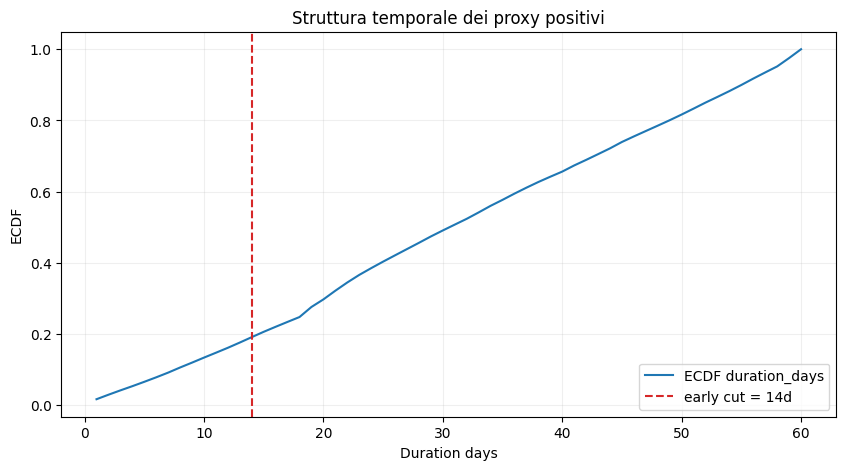

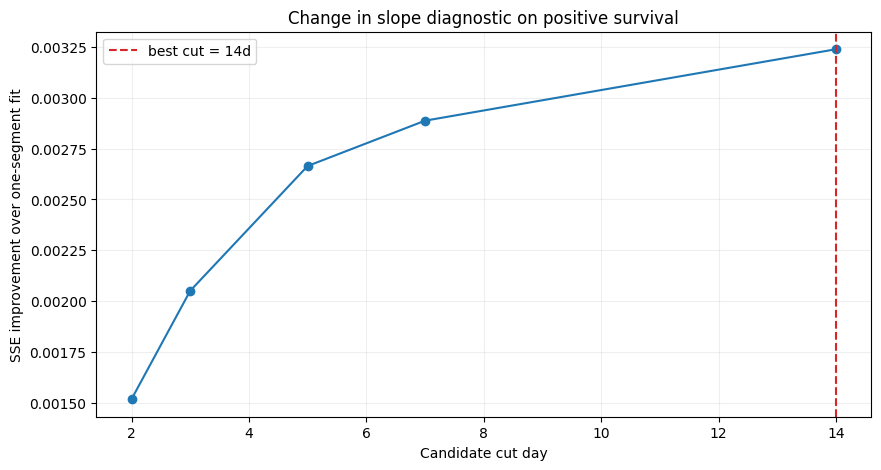

Caricamento filtrato di posts.parquet via DuckDB...
N did campionati: 5000
Filtro temporale: 2025-01-01 00:00:00+00:00 -> 2025-03-01 23:42:57.441000+00:00


,early_structure
signal_name,posts_count
decision,coverage_then_elbow
recommended_window,5
coverage_target,0.8
coverage_target_window,5
elbow_day,7
elbow_window,5
n_feasible_windows,4


,late_structure
signal_name,posts_count
decision,coverage_then_elbow
recommended_window,21
coverage_target,0.8
coverage_target_window,None
elbow_day,34
elbow_window,21
n_feasible_windows,8


,intermediate_diagnostic
signal_name,posts_count
early_window,5
late_window,21
gap_days,16
early_cumulative_share,0.315545
late_cumulative_share,0.60806
middle_gain,0.154119
intermediate_candidate_window,14
intermediate_duration_share,0.0
needs_intermediate_window_analysis,False


,structure_decision
early_cut_days,14
early_window_exists,True
early_window_days,5
late_window_days,21
needs_intermediate_window_analysis,False
intermediate_candidate_window,14
theoretical_window_count,2


...

,quantile,distance_days
0,0.50,15.453527
1,0.75,29.072700
2,0.80,32.409501
3,0.90,41.237548
4,0.95,46.889404


Sintesi account-level quantili pre-evento early:


,metric,count,mean,std,min,25%,50%,75%,max
0,n_events,1487.0,2.352387,4.927014,1.000000,1.000000,1.000000,2.000000,79.000000
1,total_value,1487.0,2.352387,4.927014,1.000000,1.000000,1.000000,2.000000,79.000000
2,q50,1487.0,0.328347,1.104103,0.041667,0.041667,0.041667,0.041667,12.023957
3,q75,1487.0,0.717296,1.729084,0.041667,0.041667,0.041667,0.049894,12.468467
4,q80,1487.0,0.797740,1.872036,0.041667,0.041667,0.041667,0.052068,12.661651
5,q90,1487.0,0.958959,2.178383,0.041667,0.041667,0.041667,0.055284,12.948446
6,q95,1487.0,1.044574,2.357785,0.041667,0.041667,0.041667,0.056986,12.950673


Sintesi account-level quantili pre-evento late:


,metric,count,mean,std,min,25%,50%,75%,max
0,n_events,3500.0,6.451429,18.494438,1.000000,1.000000,2.000000,5.000000,520.000000
1,total_value,3500.0,6.451429,18.494438,1.000000,1.000000,2.000000,5.000000,520.000000
2,q50,3500.0,5.964284,10.436780,0.041667,0.041667,0.041667,7.913815,54.967398
3,q75,3500.0,10.140134,13.493920,0.041667,0.041667,2.639699,17.536821,57.964325
4,q80,3500.0,10.955662,14.090991,0.041667,0.041667,3.292484,19.309826,57.965568
5,q90,3500.0,12.638210,15.494924,0.041667,0.041667,4.678287,23.012887,59.061974
6,q95,3500.0,13.510944,16.313337,0.041667,0.041667,5.168843,25.113517,59.485813


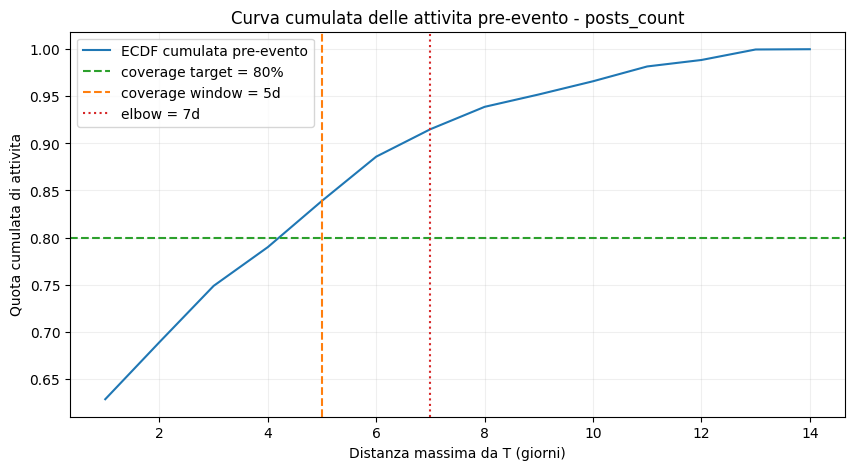

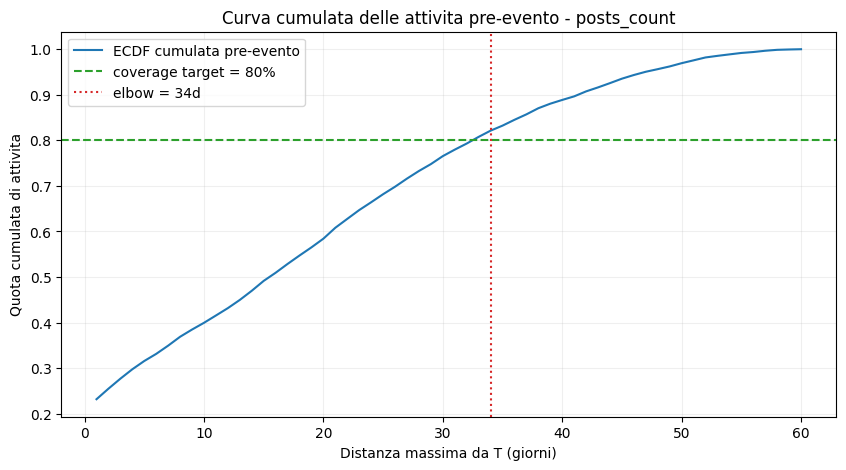

In [ ]:
print(f'Soglia early stimata: {EARLY_CUT_DAYS} giorni')
display(early_cut_diagnostics)

split_summary = pd.DataFrame([
    {'group': 'early', 'n_positives': early_n, 'share': early_share},
    {'group': 'late', 'n_positives': late_n, 'share': late_share},
])
display(split_summary)

positive_duration_quantiles = (
    positives['duration_days']
    .quantile(PRE_EVENT_QUANTILES)
    .rename_axis('quantile')
    .reset_index(name='duration_days')
)
display(positive_duration_quantiles)

print('Supporto strutturale early:')
display(early_support_table)
print('Supporto strutturale late:')
display(late_support_table)

duration_grid = np.arange(1, int(np.ceil(positives['duration_days'].max())) + 1)
duration_ecdf = pd.DataFrame({
    'duration_days': duration_grid,
    'ecdf': [(positives['duration_days'] <= d).mean() for d in duration_grid],
})
duration_ecdf['ccdf'] = 1.0 - duration_ecdf['ecdf']
duration_ecdf['ecdf_slope'] = duration_ecdf['ecdf'].diff()

display(duration_ecdf.head(20))

plt.figure(figsize=(10, 5))
plt.plot(duration_ecdf['duration_days'], duration_ecdf['ecdf'], label='ECDF duration_days')
plt.axvline(EARLY_CUT_DAYS, color='tab:red', linestyle='--', label=f'early cut = {EARLY_CUT_DAYS}d')
plt.xlabel('Duration days')
plt.ylabel('ECDF')
plt.title('Struttura temporale dei proxy positivi')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(early_cut_diagnostics['cut_day'], early_cut_diagnostics['sse_improvement'], marker='o')
plt.axvline(EARLY_CUT_DAYS, color='tab:red', linestyle='--', label=f'best cut = {EARLY_CUT_DAYS}d')
plt.xlabel('Candidate cut day')
plt.ylabel('SSE improvement over one-segment fit')
plt.title('Change in slope diagnostic on positive survival')
plt.grid(alpha=0.2)
plt.legend()
plt.show()

early_anchors = build_positive_anchors(
    accounts,
    positives_mask=early_mask,
    max_positives=min(MAX_POSITIVES_EARLY, early_n),
    random_state=RANDOM_STATE,
)

late_anchors = build_positive_anchors(
    accounts,
    positives_mask=late_mask,
    max_positives=min(MAX_POSITIVES_LATE, late_n),
    random_state=RANDOM_STATE,
)

analysis_anchors = pd.concat([early_anchors, late_anchors], ignore_index=True)
analysis_anchors = analysis_anchors.drop_duplicates(subset=['did_id']).reset_index(drop=True)

min_ref = A_ts.tz_localize('UTC')
max_ref = analysis_anchors['reference_time'].max()

print('Caricamento filtrato di posts.parquet via DuckDB...')
print('N did campionati:', analysis_anchors['did_id'].nunique())
print('Filtro temporale:', min_ref, '->', max_ref)

posts_raw = load_events_from_parquet_duckdb(
    (ROOT / POSTS_FILE).as_posix(),
    did_ids=analysis_anchors['did_id'],
    did_col='did_id',
    ts_col='created_at',
    min_time=min_ref,
    max_time=max_ref,
)

posts_events = prepare_signal_events(
    posts_raw,
    did_col='did_id',
    ts_col='event_time',
    value_col='value',
    signal_name=SIGNAL_NAME,
)
posts_events = exclude_one_event_at_reference(posts_events, analysis_anchors)

structure_early = run_informative_window_analysis(
    accounts=accounts,
    signal_events={SIGNAL_NAME: posts_events},
    A=A_ts,
    windows=EARLY_WINDOWS,
    anchors=early_anchors,
    random_state=RANDOM_STATE,
    positives_mask=early_mask,
    min_support_share=MIN_SUPPORT_SHARE,
    min_supported_positives=MIN_SUPPORTED_POSITIVES_EARLY,
    coverage_target=EARLY_COVERAGE_TARGET,
    recommendation_rule=EARLY_RECOMMENDATION_RULE,
    primary_signal_name=SIGNAL_NAME,
    pre_event_quantiles=PRE_EVENT_QUANTILES,
)

structure_late = run_informative_window_analysis(
    accounts=accounts,
    signal_events={SIGNAL_NAME: posts_events},
    A=A_ts,
    windows=LATE_WINDOWS,
    anchors=late_anchors,
    random_state=RANDOM_STATE,
    positives_mask=late_mask,
    min_support_share=MIN_SUPPORT_SHARE,
    min_supported_positives=MIN_SUPPORTED_POSITIVES_LATE,
    coverage_target=LATE_COVERAGE_TARGET,
    recommendation_rule=LATE_RECOMMENDATION_RULE,
    primary_signal_name=SIGNAL_NAME,
    pre_event_quantiles=PRE_EVENT_QUANTILES,
)

intermediate_diagnostic = assess_intermediate_window_need(
    structure_late.utility_curve,
    early_window=structure_early.recommendation.get('recommended_window'),
    late_window=structure_late.recommendation.get('recommended_window'),
    positive_durations=positives['duration_days'],
    early_cut_days=EARLY_CUT_DAYS,
    signal_name=SIGNAL_NAME,
    min_gap_days=INTERMEDIATE_MIN_GAP_DAYS,
    min_middle_gain=INTERMEDIATE_MIN_MIDDLE_GAIN,
    min_middle_duration_share=INTERMEDIATE_MIN_DURATION_SHARE,
)

structure_decision = {
    'early_cut_days': int(EARLY_CUT_DAYS),
    'early_window_exists': bool(structure_early.recommendation.get('recommended_window') is not None),
    'early_window_days': structure_early.recommendation.get('recommended_window'),
    'late_window_days': structure_late.recommendation.get('recommended_window'),
    'needs_intermediate_window_analysis': intermediate_diagnostic.get('needs_intermediate_window_analysis'),
    'intermediate_candidate_window': intermediate_diagnostic.get('intermediate_candidate_window'),
}
structure_decision['theoretical_window_count'] = (
    3 if structure_decision['needs_intermediate_window_analysis']
    else 2 if structure_decision['early_window_exists']
    else 1
)

display(pd.Series(structure_early.recommendation, name='early_structure').to_frame())
display(pd.Series(structure_late.recommendation, name='late_structure').to_frame())
display(pd.Series(intermediate_diagnostic, name='intermediate_diagnostic').to_frame())
display(pd.Series(structure_decision, name='structure_decision').to_frame())

print('Quantili temporali pre-evento early:')
display(structure_early.global_quantiles)
print('Quantili temporali pre-evento late:')
display(structure_late.global_quantiles)
print('Sintesi account-level quantili pre-evento early:')
display(structure_early.account_quantile_summary)
print('Sintesi account-level quantili pre-evento late:')
display(structure_late.account_quantile_summary)

plot_pre_event_global_curve(
    structure_early.global_curve,
    SIGNAL_NAME,
    coverage_target=EARLY_COVERAGE_TARGET,
    coverage_window=structure_early.recommendation.get('coverage_target_window'),
    elbow_day=structure_early.recommendation.get('elbow_day'),
)
plot_pre_event_global_curve(
    structure_late.global_curve,
    SIGNAL_NAME,
    coverage_target=LATE_COVERAGE_TARGET,
    coverage_window=structure_late.recommendation.get('coverage_target_window'),
    elbow_day=structure_late.recommendation.get('elbow_day'),
)


## 2. Definizione finestre candidate

Questa sezione traduce i risultati esplorativi della sezione precedente in durate esplicite in giorni. Qui fissiamo quindi una prima definizione delle finestre candidate da usare nel seguito: una finestra `early` se la sezione strutturale dice che ha senso, una o piu finestre `late` derivate dalla griglia della utility window, ed eventualmente una finestra `intermedia` solo come ipotesi metodologica. In questa fase non cambiamo ancora la logica implementata nel `.py`: stiamo solo trasformando i risultati esplorativi in un set chiaro di durate candidate.


In [ ]:
EARLY_WINDOW_DAYS = structure_early.recommendation.get('recommended_window')
LATE_WINDOW_PRIMARY = structure_late.recommendation.get('recommended_window')
LATE_WINDOW_ELBOW = structure_late.recommendation.get('elbow_window')
LATE_FEASIBLE_WINDOWS = (
    structure_late.decision_table
    .loc[structure_late.decision_table['feasible'], 'window_days']
    .astype(int)
    .tolist()
)
INTERMEDIATE_WINDOW_DAYS = intermediate_diagnostic.get('intermediate_candidate_window')

candidate_windows = pd.DataFrame([
    {
        'window_role': 'early',
        'window_days': EARLY_WINDOW_DAYS,
        'status': 'candidate' if EARLY_WINDOW_DAYS is not None else 'not_supported',
        'source': 'early exploratory ECDF',
    },
    {
        'window_role': 'late_primary',
        'window_days': LATE_WINDOW_PRIMARY,
        'status': 'candidate',
        'source': 'late coverage recommendation',
    },
    {
        'window_role': 'late_elbow',
        'window_days': LATE_WINDOW_ELBOW,
        'status': 'candidate' if LATE_WINDOW_ELBOW is not None else 'not_available',
        'source': 'late ECDF elbow',
    },
    {
        'window_role': 'intermediate',
        'window_days': INTERMEDIATE_WINDOW_DAYS,
        'status': 'diagnostic_only' if INTERMEDIATE_WINDOW_DAYS is not None else 'not_suggested',
        'source': 'intermediate diagnostic',
    },
])

late_candidate_windows = sorted(set(int(w) for w in LATE_FEASIBLE_WINDOWS if pd.notna(w)))
if not late_candidate_windows:
    late_candidate_windows = sorted(set(int(w) for w in LATE_WINDOWS))

candidate_definition = {
    'theoretical_window_count': structure_decision['theoretical_window_count'],
    'early_window_days': EARLY_WINDOW_DAYS,
    'late_candidate_windows': late_candidate_windows,
    'late_primary_window': LATE_WINDOW_PRIMARY,
    'late_elbow_window': LATE_WINDOW_ELBOW,
    'intermediate_window_days': INTERMEDIATE_WINDOW_DAYS,
}

display(candidate_windows)
display(pd.Series(candidate_definition, name='candidate_definition').to_frame())


,window_role,window_days,status,source
0,early,5,candidate,early exploratory ECDF
1,late_primary,21,candidate,late coverage recommendation
2,late_elbow,21,candidate,late ECDF elbow
3,intermediate,14,diagnostic_only,intermediate diagnostic


,candidate_definition
theoretical_window_count,2
early_window_days,5
late_candidate_windows,"[1, 2, 3, 5, 7, 10, 14, 21]"
late_primary_window,21
late_elbow_window,21
intermediate_window_days,14


## 3. Implementazione operativa (solo early e late)

In questa sezione il notebook smette di essere puramente esplorativo e applica la stessa logica gia implementata nel file [proxy_td_informative_window.py](/C:/Users/Nico/Documents/Bluesky/Bluesky-moderation-analysis/analysis/proxy_td_informative_window.py). Anche se la sezione strutturale avesse suggerito una possibile scala intermedia, qui implementiamo operativamente solo due finestre: `early` e `late`.

Per `early` usiamo, se esiste, la finestra preliminare stimata nella sezione 2. Per `late` applichiamo la stessa pipeline ECDF del `.py`, ma limitandoci all insieme esplicito di finestre candidate derivate dalla utility window. Le feature vengono quindi calcolate esattamente sugli intervalli `[T-w, T)` definiti in questa fase, sempre con esclusione dell ultimo post all anchor.


In [ ]:
operational_early = None
if EARLY_WINDOW_DAYS is not None:
    operational_early = run_informative_window_analysis(
        accounts=accounts,
        signal_events={SIGNAL_NAME: posts_events},
        A=A_ts,
        windows=[int(EARLY_WINDOW_DAYS)],
        anchors=early_anchors,
        random_state=RANDOM_STATE,
        positives_mask=early_mask,
        min_support_share=MIN_SUPPORT_SHARE,
        min_supported_positives=MIN_SUPPORTED_POSITIVES_EARLY,
        coverage_target=EARLY_COVERAGE_TARGET,
        recommendation_rule=EARLY_RECOMMENDATION_RULE,
        primary_signal_name=SIGNAL_NAME,
        pre_event_quantiles=PRE_EVENT_QUANTILES,
    )

    early_feature_cols = [
        c for c in operational_early.features.columns
        if c.endswith('__total_observed') or f'__w{int(EARLY_WINDOW_DAYS)}' in c
    ]
    print('Intervallo operativo early:', f'[T-{int(EARLY_WINDOW_DAYS)}, T)')
    display(pd.Series(operational_early.recommendation, name='operational_early').to_frame())
    display(operational_early.features[early_feature_cols].describe().T)
else:
    print('Nessuna early window supportata: l implementazione operativa resta solo sul regime late.')

operational_late = run_informative_window_analysis(
    accounts=accounts,
    signal_events={SIGNAL_NAME: posts_events},
    A=A_ts,
    windows=late_candidate_windows,
    anchors=late_anchors,
    random_state=RANDOM_STATE,
    positives_mask=late_mask,
    min_support_share=MIN_SUPPORT_SHARE,
    min_supported_positives=MIN_SUPPORTED_POSITIVES_LATE,
    coverage_target=LATE_COVERAGE_TARGET,
    recommendation_rule=LATE_RECOMMENDATION_RULE,
    primary_signal_name=SIGNAL_NAME,
    pre_event_quantiles=PRE_EVENT_QUANTILES,
)

late_feature_cols = [
    c for c in operational_late.features.columns
    if c.endswith('__total_observed') or any(f'__w{w}' in c for w in late_candidate_windows)
]
print('Finestre operative late candidate:', late_candidate_windows)
display(pd.Series(operational_late.recommendation, name='operational_late').to_frame())
display(operational_late.features[late_feature_cols].describe().T)


Intervallo operativo early: [T-5, T)


,operational_early
signal_name,posts_count
decision,coverage_then_elbow
recommended_window,5
coverage_target,0.8
coverage_target_window,5
elbow_day,7
elbow_window,5
n_feasible_windows,1


,count,mean,std,min,25%,50%,75%,max
posts_count__total_observed,1500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w5,1000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Finestre operative late candidate: [1, 2, 3, 5, 7, 10, 14, 21]


,operational_late
signal_name,posts_count
decision,coverage_then_elbow
recommended_window,21
coverage_target,0.8
coverage_target_window,None
elbow_day,34
elbow_window,21
n_feasible_windows,8


,count,mean,std,min,25%,50%,75%,max
posts_count__total_observed,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w1,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w2,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w3,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w5,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w7,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w10,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w14,3500.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
posts_count__w21,2925.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 4. Decisione finale sulla late window

Questa sezione confronta le candidate `late` derivate dalla griglia della utility window usando solo statistiche descrittive e stabilita delle feature, senza introdurre modelli predittivi. Il punto non e creare una logica alternativa a quella del `.py`, ma usare il notebook per validare e interpretare la scelta finale.

Per ogni finestra `late` confrontiamo quindi: copertura cumulata globale, supporto strutturale, numerosita valida, intensita media del segnale nella finestra, quote di attivita catturata e misure semplici di stabilita/eterogeneita. La scelta finale della `late window` da usare nelle analisi successive resta quella prodotta dalla pipeline operativa, ma qui viene accompagnata da una lettura descrittiva che rende la decisione piu trasparente.


,window_days,support_share,n_positive_supported,n_accounts_valid,valid_share,active_share,window_value_mean,window_value_median,window_value_std,window_value_p75,window_value_p90,capture_share_mean,capture_share_median,capture_share_p75,capture_share_p90,global_cumulative_share,incremental_global_share,corr_window_total_spearman,corr_window_duration_spearman,feasible,reaches_coverage_target
0,1,1.000000,1147583,3500,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.231621,0.231621,NaN,NaN,True,False
1,2,1.000000,1147583,3500,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.254739,0.023118,NaN,NaN,True,False
2,3,1.000000,1147583,3500,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.276749,0.022011,NaN,NaN,True,False
3,5,1.000000,1147583,3500,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.315545,0.038795,NaN,NaN,True,False
4,7,1.000000,1147583,3500,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.349247,0.033702,NaN,NaN,True,False
5,10,1.000000,1147583,3500,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.399380,0.050133,NaN,NaN,True,False
6,14,1.000000,1147583,3500,1.000000,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.469663,0.070283,NaN,NaN,True,False
7,21,0.838783,962573,2925,0.835714,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,0.608060,0.138397,NaN,NaN,True,False


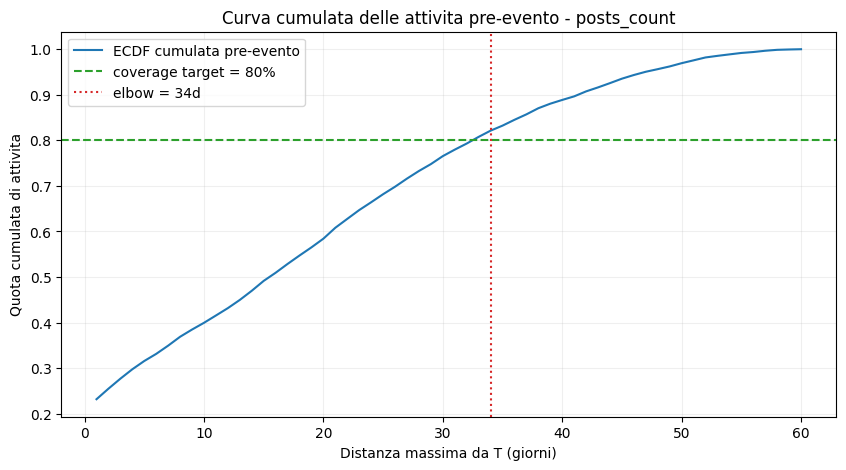

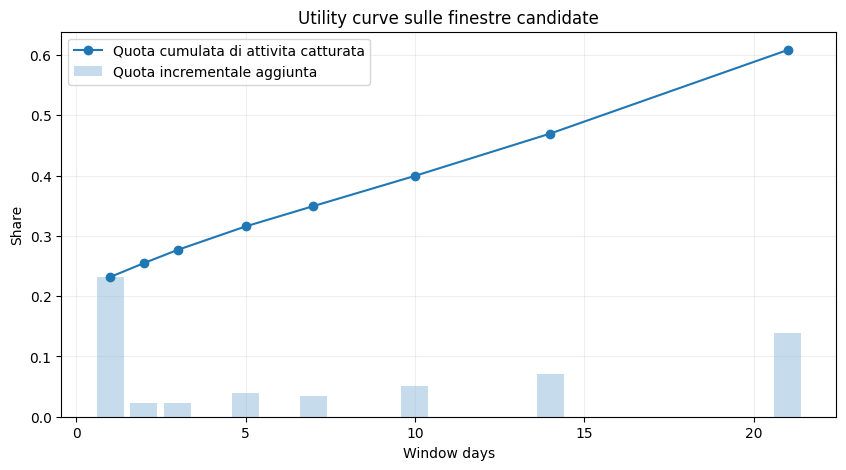

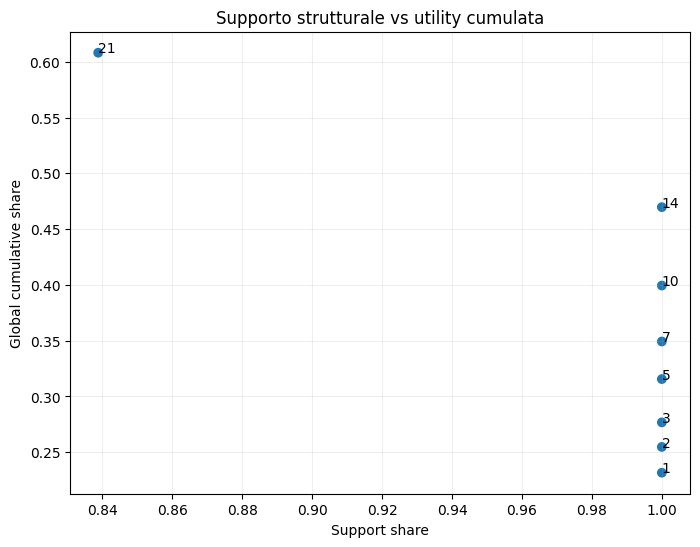

,final_decision
theoretical_window_count,2
split_cut_days,14
early_window_exists,True
early_window_days,5
late_candidate_windows,"[1, 2, 3, 5, 7, 10, 14, 21]"
final_late_window_days,21
late_decision_rule,coverage_then_elbow
late_coverage_target_window,None
late_elbow_window,21
needs_intermediate_window_analysis,False


In [ ]:
late_candidate_comparison = operational_late.decision_table[
    [
        'window_days',
        'support_share',
        'n_positive_supported',
        'n_accounts_valid',
        'valid_share',
        'active_share',
        'window_value_mean',
        'window_value_median',
        'window_value_std',
        'window_value_p75',
        'window_value_p90',
        'capture_share_mean',
        'capture_share_median',
        'capture_share_p75',
        'capture_share_p90',
        'global_cumulative_share',
        'incremental_global_share',
        'corr_window_total_spearman',
        'corr_window_duration_spearman',
        'feasible',
        'reaches_coverage_target',
    ]
].copy().sort_values('window_days')

FINAL_LATE_WINDOW_DAYS = operational_late.recommendation.get('recommended_window')

final_decision = {
    'theoretical_window_count': structure_decision['theoretical_window_count'],
    'split_cut_days': int(EARLY_CUT_DAYS),
    'early_window_exists': EARLY_WINDOW_DAYS is not None,
    'early_window_days': EARLY_WINDOW_DAYS,
    'late_candidate_windows': late_candidate_windows,
    'final_late_window_days': FINAL_LATE_WINDOW_DAYS,
    'late_decision_rule': operational_late.recommendation.get('decision'),
    'late_coverage_target_window': operational_late.recommendation.get('coverage_target_window'),
    'late_elbow_window': operational_late.recommendation.get('elbow_window'),
    'needs_intermediate_window_analysis': intermediate_diagnostic.get('needs_intermediate_window_analysis'),
    'intermediate_candidate_window': intermediate_diagnostic.get('intermediate_candidate_window'),
}

display(late_candidate_comparison)
plot_pre_event_global_curve(
    operational_late.global_curve,
    SIGNAL_NAME,
    coverage_target=LATE_COVERAGE_TARGET,
    coverage_window=operational_late.recommendation.get('coverage_target_window'),
    elbow_day=operational_late.recommendation.get('elbow_day'),
)
plot_utility_curve(operational_late.utility_curve)
plot_support_vs_utility(operational_late.decision_table)

display(pd.Series(final_decision, name='final_decision').to_frame())
